[INFO] Memuat Dataset VENEZUELA DOMAIN: extracted_data_1c_venez.json


No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.


Accuracy: [0.5021865889212828, 0.5021865889212828]
Accuracy (avg.): 0.5021865889212828
True positive rate: [0.6246355685131195, 0.37973760932944606]
True positive rate (avg.): 0.5021865889212828
True negative rate: [0.37973760932944606, 0.6246355685131195]
True negative rate (avg.): 0.5021865889212828
Positive predictive value: [0.5017564402810304, 0.502895752895753]
Positive predictive value (avg.): 0.5023260965883917
Negative predictive value: [0.502895752895753, 0.5017564402810304]
Negative predictive value (avg.): 0.5023260965883917
False positive rate: [0.6202623906705539, 0.3753644314868805]
False positive rate (avg.): 0.4978134110787172
False negative rate: [0.3753644314868805, 0.6202623906705539]
False negative rate (avg.): 0.4978134110787172
False discovery rate: [0.49824355971896955, 0.4971042471042471]
False discovery rate (avg.): 0.4976739034116083
F1-score: [0.5564935064935065, 0.4327242524916944]
F1-score (avg.): 0.49460887949260046
[INFO] Grafik metrik tersimpan di: /Vol

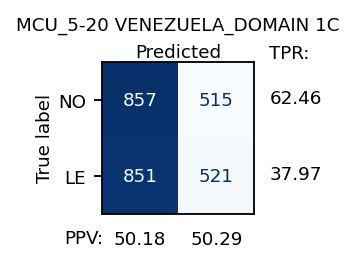

In [10]:
# -*- coding: utf-8 -*-
from Library import utils, dataset
import os
from tensorflow import keras
from tqdm import tqdm
import numpy as np
from datetime import datetime
import logging
import matplotlib.pyplot as plt   # <--- ditambahkan

# Fungsi plot (sama seperti sebelumnya) dengan perbaikan
def plot_comprehensive_metrics(metrics, save_path):
    labels = ['Accuracy', 'Recall', 'Precision', 'FPR', 'F1-Score']
    keys = [
        'Accuracy (avg.)', 
        'True positive rate (avg.)', 
        'Positive predictive value (avg.)', 
        'False positive rate (avg.)', 
        'F1-score (avg.)'
    ]
    values = [metrics.get(k, 0) for k in keys]
    plt.figure(figsize=(12, 6))
    bars = plt.bar(labels, values, color=['#2c3e50', '#3498db', '#e67e22', '#e74c3c', '#27ae60'])
    plt.ylim(0, 1.0)
    plt.ylabel('Score')
    plt.title('Performance Metrics Evaluation (Average) - Venezuela 3C')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()
    # Bisa pakai print atau logger, terserah
    print(f"[INFO] Grafik metrik tersimpan di: {save_path}")

# Main execution
if __name__ == "__main__":
                  
    #===================================================================
    #                    1. KONFIGURASI PATH STEAD
    #===================================================================
    # Path dataset sesi 1
    #KEY_DATA_DIR = "/Volumes/Extreme SSD/output_json_indonesia"
    #KEY_TEST_FILE = "extracted_data.json" 
    
    # ===================================================================
    # Konfigurasi untuk pengujian VENEZUELA DOMAIN sesi 3
    #===================================================================

    #KEY_DATA_DIR = '/Volumes/Extreme SSD/unduhan_waveform_merged'
    #KEY_TEST_FILE = 'extracted_data.json'

    KEY_DATA_DIR = "/Volumes/Extreme SSD/venezuela_data_earthquake/json_venezuela"
    KEY_TEST_FILE = "extracted_data_1c_venez.json"

    DATA_TAG = "VENEZUELA_DOMAIN"
    MODEL_TAG = "MCU_5-20"
    INPUT_WIN = 7 
    SAMPLING_RATE = 100
    
    # STEAD fokus pada Noise (NO) dan Earthquake (LE)
    true_labels = ["NO", "LE"]
    source_to_code = {"noise": 0, "le": 1}

    # Path Model dan Embedding (PASTIKAN MENGGUNAKAN EMBEDDING STEAD)
    BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mulai_juli/mcquake_ori_file/Code & Figure demo"
    MODEL_PATH = os.path.join(BASE_REP, "Pre-trained model/MCU-Quake 5-20")
    
    # Path Embedding Khusus STEAD (n=61099) atau UUSS (n=11275) opsi: gunakan salah satu, jangan keduanya
    #EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, STEAD norm7 mag3 L n61099, 30172538")
    EMB_DIR = os.path.join(BASE_REP, "Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909")
    #===================================================================
    #                           2. PREPARE FILES
    #===================================================================
    print(f"[INFO] Memuat Dataset VENEZUELA DOMAIN: {KEY_TEST_FILE}")
    test_data = dataset.load_json_data(os.path.join(KEY_DATA_DIR, KEY_TEST_FILE))
    
    SAVE_BASE = '/Volumes/Extreme SSD/venezuela_data_earthquake/visualisasi_venezuela'
    now = datetime.now()
    time_str = now.strftime("%d%H%M%S")
    save_dir = os.path.join(SAVE_BASE, f"{MODEL_TAG}_{DATA_TAG}_{time_str}")
    if not os.path.exists(save_dir): os.makedirs(save_dir)

    # Logger
    log_file_path = os.path.join(save_dir, "task_log_venezuela_domain.txt")
    logging.basicConfig(filename=log_file_path, level=logging.INFO, filemode='w',
                        format='%(asctime)s - [%(levelname)s]: %(message)s')
    logger = logging.getLogger()
    logger.addHandler(logging.StreamHandler())

    # Load Model & Embeddings STEAD
    embedding_model = keras.models.load_model(filepath=MODEL_PATH)
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    embedding_N = dataset.load_embedding_data(EMB_DIR, "Embedding data, N.json")
    embedding_E = dataset.load_embedding_data(EMB_DIR, "Embedding data, E.json")

    logger.info(f"Estimating VENEZUELA DOMAIN embeddings statistics (KDE)...")
    # Menggunakan statistik ruang laten VENEZUELA DOMAIN
    embeddings_3C_PDFs = utils.embedding_PDFs_3D(embedding_Z, embedding_N, embedding_E)

    #===================================================================
    #                            3. EVALUATION
    #===================================================================
    total_true_3C, total_pred_3C = [], []
    num_points = int(INPUT_WIN * SAMPLING_RATE)
    keys_list = list(test_data.keys())

    logger.info(f"Memproses {len(keys_list)} data VENEZUELA DOMAIN...")

    for i in tqdm(range(len(keys_list)), desc="Inference VENEZUELA DOMAIN"):
        record_key = keys_list[i]
        record = test_data[record_key]
        quake_label = record["type"] # label asli: 'le'
    
        try:
            # Hanya ambil Z
            Z_n = record["Z_noise"][-num_points:]
            Z_s = record["Z"][:num_points]

            # Embedding Z saja
            _in_Zn = utils.latent_codes_1D(Z_n, embedding_model)
            _in_Zs = utils.latent_codes_1D(Z_s, embedding_model)

            # Karena model MCU-Quake 3C mengharapkan 3 komponen, 
            # kita berikan Z untuk ketiga slot input (E, N, Z) sebagai workaround
            emb_n = np.array([_in_Zn, _in_Zn, _in_Zn]).reshape(1,-1)
            p_n, _, _ = utils.infer_3C_PDFs(emb_n, embeddings_3C_PDFs, "Kernel")
            
            emb_s = np.array([_in_Zn, _in_Zn, _in_Zs]).reshape(1,-1) # Z_s untuk Z
            p_s, _, _ = utils.infer_3C_PDFs(emb_s, embeddings_3C_PDFs, "Kernel")
            
            total_true_3C.extend([0, 1]) 
            total_pred_3C.extend([1 if p_n >= 1 else 0, 1 if p_s >= 1 else 0])
            
        except Exception as e:
            logger.error(f"Error pada {record_key}: {e}")
            continue

    #===================================================================
    #                        4. METRICS & SAVE
    #===================================================================

    matrix_1C, metrics_1C = utils.calc_confusion_metrics(total_true_3C, total_pred_3C)
    
    # Visualisasi
    fig_1C = utils.plot_confusion(f"{MODEL_TAG} {DATA_TAG} 1C", true_labels, matrix_1C, metrics_1C)
    fig_1C.savefig(os.path.join(save_dir, "Venezuela_domain_1C.jpg"), dpi=300)
    
    dataset.save_json_data(os.path.join(save_dir, "venezuela_domain_metrics.json"), metrics_1C)
    # Plot comprehensive metrics
    plot_comprehensive_metrics(metrics_1C, os.path.join(save_dir, "venezuela_domain_1C_metrics_bar.jpg"))
        
    logger.info("\n" + "="*40)
    logger.info(f"VENEZUELA DOMAIN ACCURACY: {metrics_1C.get('accuracy (avg.)')}")
    logger.info(f"VENEZUELA DOMAIN F1-SCORE: {metrics_1C.get('f1-score (avg.)')}")
    logger.info("="*40)
    logger.info("Pengujian VENEZUELA DOMAIN Selesai.")


   

In [7]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
VISUALISASI HASIL BENCHMARKING MCU-QUAKE DI DATA INDONESIA
- Confusion Matrix
- Distribusi Embedding (opsional)
- Metrics Summary dengan Specificity (TNR)
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
import os
from pathlib import Path

# =============================================
# 1. KONFIGURASI
# =============================================

# --- Data Confusion Matrix (dari hasil benchmarking Anda) ---
# Format: [[TP, FP], [FN, TN]]
# NO (Noise)  : TP=7453, FP=5486
# LE (Gempa)  : FN=2414, TN=10525
confusion_data = {
    "NO": {"TP": 7453, "FP": 5486},
    "LE": {"FN": 2414, "TN": 10525}
}

# --- Jika Anda memiliki file hasil inferensi dengan embedding ---
# EMBEDDING_FILE = "/path/to/embedding_results.csv"  # atau .json
EMBEDDING_FILE = None  # set None jika tidak ada

# --- Output folder ---
OUTPUT_DIR = '/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/indonesia_domain/nUUSS_embedding/MCU_5-20_INDONESIA_DOMAIN_21073016/visualisasi'
Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

# =============================================
# 2. FUNGSI VISUALISASI
# =============================================

def plot_confusion_matrix(confusion_data, output_dir):
    """
    Plot confusion matrix dari data benchmarking.
    """
    # Buat confusion matrix 2x2
    cm = np.array([
        [confusion_data["NO"]["TP"], confusion_data["NO"]["FP"]],
        [confusion_data["LE"]["FN"], confusion_data["LE"]["TN"]]
    ])
    
    labels = ["NO (Noise)", "LE (Gempa)"]
    
    # Normalisasi ke persentase (opsional)
    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot absolut
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels, ax=ax1,
                cbar=False)
    ax1.set_title('Confusion Matrix (Absolute)', fontsize=14)
    ax1.set_xlabel('Predicted Label')
    ax1.set_ylabel('True Label')
    
    # Plot persentase
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax2,
                cbar=True, vmin=0, vmax=100)
    ax2.set_title('Confusion Matrix (Percentage)', fontsize=14)
    ax2.set_xlabel('Predicted Label')
    ax2.set_ylabel('True Label')
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Confusion matrix saved to {output_dir}/confusion_matrix.png")
    
    # Simpan juga angka ke file CSV
    df_cm = pd.DataFrame(cm, index=labels, columns=labels)
    df_cm.to_csv(os.path.join(output_dir, 'confusion_matrix.csv'))
    print(f"✅ Confusion matrix CSV saved to {output_dir}/confusion_matrix.csv")
    
    return cm

def plot_embedding_distribution(embedding_file, output_dir):
    """
    Plot distribusi embedding jika data tersedia.
    """
    # Load data
    if embedding_file.endswith('.csv'):
        df = pd.read_csv(embedding_file)
    elif embedding_file.endswith('.json'):
        with open(embedding_file, 'r') as f:
            data = json.load(f)
        df = pd.DataFrame(data)
    else:
        raise ValueError("File harus berformat .csv atau .json")
    
    # Asumsikan ada kolom: 'embedding' dan 'true_label' (atau 'label')
    # Jika tidak, coba deteksi
    if 'embedding' not in df.columns:
        # Cari kolom yang berisi embedding (biasanya bernama 'embedding', 'emb', 'z_embedding', dll)
        emb_cols = [c for c in df.columns if 'embedding' in c.lower() or 'emb' in c.lower()]
        if emb_cols:
            emb_col = emb_cols[0]
        else:
            emb_col = df.columns[0]  # fallback
    else:
        emb_col = 'embedding'
    
    label_col = None
    for c in df.columns:
        if 'label' in c.lower() or 'class' in c.lower() or 'true' in c.lower():
            label_col = c
            break
    if label_col is None:
        # Jika tidak ada kolom label, buat satu (semua dianggap gempa)
        print("⚠️ Kolom label tidak ditemukan. Semua data dianggap sebagai 'Gempa'.")
        df['label'] = 'LE'
        label_col = 'label'
    
    # Mapping label jika perlu (sesuai paper)
    label_map = {'NO': 'Noise', 'LE': 'Earthquake', 'EX': 'Explosion'}
    df['label_display'] = df[label_col].map(label_map).fillna(df[label_col])
    
    # Plot histogram
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Warna sesuai paper
    colors = {'Noise': 'grey', 'Earthquake': 'blue', 'Explosion': 'red'}
    
    for lbl in df['label_display'].unique():
        subset = df[df['label_display'] == lbl][emb_col]
        ax.hist(subset, bins=50, alpha=0.6, label=lbl, color=colors.get(lbl, 'blue'), density=True)
    
    # Garis vertikal referensi dari paper
    ref_values = {
        'Noise': -5.01,
        'Earthquake': 1.01,
        'Explosion': 1.96
    }
    for lbl, val in ref_values.items():
        if lbl in df['label_display'].unique():
            ax.axvline(val, color='black', linestyle='--', alpha=0.7, linewidth=1.5)
            ax.text(val, ax.get_ylim()[1]*0.9, f'Paper: {lbl}\n{val}', ha='center', fontsize=9)
    
    ax.set_xlabel('Embedding Value', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title('Distribusi Embedding MCU-Quake: Data Indonesia vs Referensi Paper', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'embedding_distribution.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Embedding distribution saved to {output_dir}/embedding_distribution.png")
    
    # Statistik deskriptif
    stats = df.groupby('label_display')[emb_col].agg(['mean', 'std', 'count']).round(4)
    stats.to_csv(os.path.join(output_dir, 'embedding_statistics.csv'))
    print(f"✅ Embedding statistics saved to {output_dir}/embedding_statistics.csv")
    print("\n📊 Statistik Embedding:")
    print(stats)

def plot_metrics_summary(confusion_data, output_dir):
    """
    Plot ringkasan metrik (Accuracy, Precision, Recall, Specificity, F1) dalam bentuk bar chart.
    """
    # Ekstrak nilai dari confusion matrix
    TP_no = confusion_data["NO"]["TP"]
    FP_no = confusion_data["NO"]["FP"]
    FN_no = confusion_data["LE"]["FN"]   # FN untuk NO adalah LE yang salah prediksi
    TN_no = confusion_data["LE"]["TN"]   # TN untuk NO adalah LE yang benar

    # Untuk kelas LE, kita definisikan ulang dari perspektif LE:
    # TP_LE = jumlah LE yang benar (TN_no)
    # FP_LE = jumlah LE yang salah (FN_no)
    # FN_LE = jumlah LE yang terlewat (FP_no)
    # TN_LE = jumlah LE yang benar (TP_no)
    TP_le = TN_no
    FP_le = FN_no
    FN_le = FP_no
    TN_le = TP_no

    # Fungsi untuk menghitung metrik
    def calc_metrics(TP, FP, FN, TN):
        total = TP + FP + FN + TN
        acc = (TP + TN) / total if total > 0 else 0
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        return acc, precision, recall, specificity, f1

    # Hitung metrik untuk Noise
    acc_no, prec_no, rec_no, spec_no, f1_no = calc_metrics(TP_no, FP_no, FN_no, TN_no)
    # Hitung metrik untuk Gempa
    acc_le, prec_le, rec_le, spec_le, f1_le = calc_metrics(TP_le, FP_le, FN_le, TN_le)

    # Akurasi keseluruhan
    total = TP_no + FP_no + FN_no + TN_no
    overall_acc = (TP_no + TN_no) / total

    # Buat dataframe metrik per kelas
    metrics_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'Specificity (TNR)', 'F1-Score'],
        'Noise (%)': [acc_no*100, prec_no*100, rec_no*100, spec_no*100, f1_no*100],
        'Earthquake (%)': [acc_le*100, prec_le*100, rec_le*100, spec_le*100, f1_le*100]
    })

    # Plot bar chart
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(metrics_df['Metric']))
    width = 0.35

    ax.bar(x - width/2, metrics_df['Noise (%)'], width, label='Noise', color='grey')
    ax.bar(x + width/2, metrics_df['Earthquake (%)'], width, label='Earthquake', color='blue')

    ax.set_xlabel('Metric', fontsize=12)
    ax.set_ylabel('Percentage (%)', fontsize=12)
    ax.set_title('Performance Metrics per Class (Indonesia Benchmark)', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_df['Metric'], rotation=15, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    # Tambahkan nilai di atas bar
    for i, row in metrics_df.iterrows():
        no_val = row['Noise (%)']
        le_val = row['Earthquake (%)']
        ax.text(i - width/2, no_val + 0.5, f'{no_val:.1f}', ha='center', va='bottom', fontsize=8)
        ax.text(i + width/2, le_val + 0.5, f'{le_val:.1f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'metrics_summary.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Metrics summary saved to {output_dir}/metrics_summary.png")

    # Simpan ke CSV
    metrics_df.to_csv(os.path.join(output_dir, 'metrics_summary.csv'), index=False)
    print(f"✅ Metrics summary CSV saved to {output_dir}/metrics_summary.csv")

    # Cetak ke terminal
    print("\n📊 Performance Metrics:")
    print(f"Overall Accuracy: {overall_acc*100:.2f}%")
    print(metrics_df.to_string(index=False))

    # Juga cetak Specificity (TNR) secara terpisah untuk kejelasan
    print("\n🔍 Specificity (True Negative Rate):")
    print(f"  - Noise    : {spec_no*100:.2f}%  (proporsi gempa yang benar diklasifikasi sebagai gempa)")
    print(f"  - Gempa    : {spec_le*100:.2f}%  (proporsi noise yang benar diklasifikasi sebagai noise)")

    return metrics_df

# =============================================
# 3. MAIN
# =============================================

def main():
    print("="*60)
    print("📊 VISUALISASI HASIL BENCHMARKING MCU-QUAKE")
    print("="*60)
    
    # 1. Confusion Matrix
    cm = plot_confusion_matrix(confusion_data, OUTPUT_DIR)
    
    # 2. Metrics Summary (dengan Specificity)
    metrics_df = plot_metrics_summary(confusion_data, OUTPUT_DIR)
    
    # 3. Embedding Distribution (jika ada)
    if EMBEDDING_FILE and os.path.exists(EMBEDDING_FILE):
        print(f"\n📂 Memuat file embedding: {EMBEDDING_FILE}")
        plot_embedding_distribution(EMBEDDING_FILE, OUTPUT_DIR)
    else:
        print("\n⚠️ File embedding tidak ditemukan atau tidak disediakan. Lewati plot distribusi.")
        print("   Untuk plot distribusi, sediakan file CSV/JSON dengan kolom 'embedding' dan 'true_label'.")
    
    print(f"\n✅ Semua visualisasi disimpan di folder: {OUTPUT_DIR}/")
    print("="*60)

if __name__ == "__main__":
    main()

📊 VISUALISASI HASIL BENCHMARKING MCU-QUAKE
✅ Confusion matrix saved to /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/indonesia_domain/nUUSS_embedding/MCU_5-20_INDONESIA_DOMAIN_21073016/visualisasi/confusion_matrix.png
✅ Confusion matrix CSV saved to /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/indonesia_domain/nUUSS_embedding/MCU_5-20_INDONESIA_DOMAIN_21073016/visualisasi/confusion_matrix.csv
✅ Metrics summary saved to /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/indonesia_domain/nUUSS_embedding/MCU_5-20_INDONESIA_DOMAIN_21073016/visualisasi/metrics_summary.png
✅ Metrics summary CSV saved to /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/indonesia_domain/nUUSS_embedding/MCU_5-20_INDONESIA_DOMAIN_21073016/visualisasi/metrics_summary.csv

📊 Performance Metrics:
Overall Accuracy: 69.47%
              Metric  Noise (%)  Earthquake (%)
            Accuracy  69.472138       69.472138
           Precision  57.601051       81.343226
Recall (Sensitivity)  75.534610 